# Sandbox: Hypothesis Testing

Проверка 5 ключевых гипотез о факторах спроса: землетрясение, перенесённые праздники, цена нефти, промо vs зарплата, сезонность школьных товаров.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

data_dir = os.path.join('..', 'data')
train = pd.read_csv(os.path.join(data_dir, 'train.csv'), parse_dates=['date']).drop(columns=['id'])
stores = pd.read_csv(os.path.join(data_dir, 'stores.csv'))
oil = pd.read_csv(os.path.join(data_dir, 'oil.csv'), parse_dates=['date'])
holidays = pd.read_csv(os.path.join(data_dir, 'holidays_events.csv'), parse_dates=['date'])

train['family'] = train['family'].astype('category')
print('Data loaded.')

Data loaded.


## Гипотеза 1: Влияние землетрясения (Апрель 16, 2016)

Гипотеза: в магазинах, расположенных вблизи эпицентра, спрос на товары первой необходимости (ПРОДОВОЛЬСТВИЕ I, НАПИТКИ) резко возрастает через 3–7 дней после события по сравнению с прошлым годом, в то время как в удаленных магазинах такого не наблюдается.

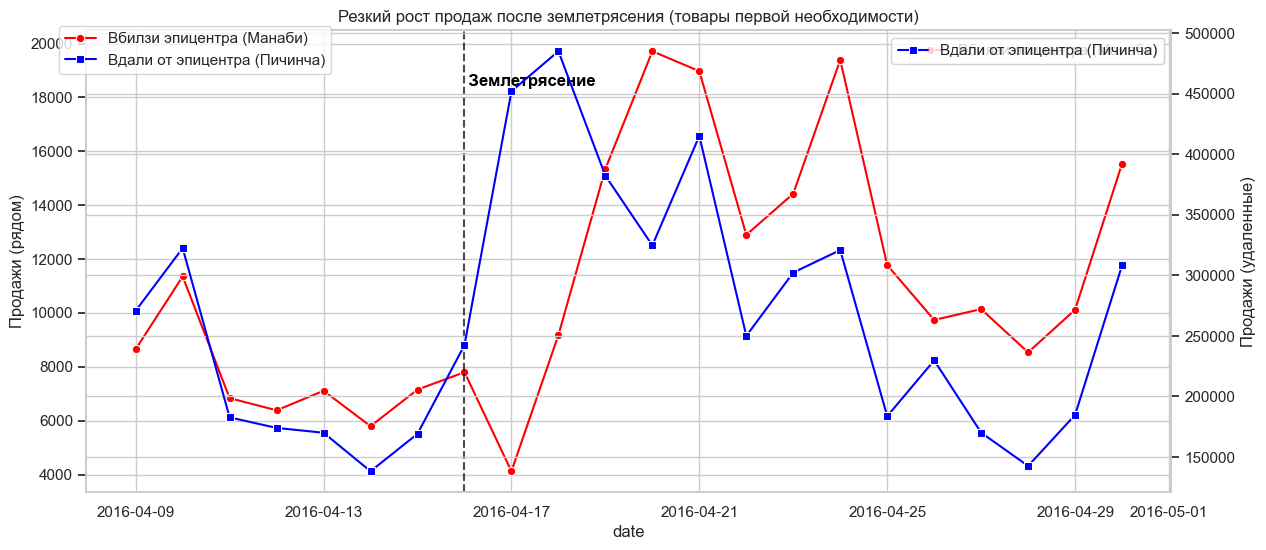

In [2]:
earthquake_date = pd.Timestamp('2016-04-16')
essential_families = ['GROCERY I', 'BEVERAGES']

near_stores = stores[stores['state'] == 'Manabi']['store_nbr'].unique()
remote_stores = stores[stores['state'] == 'Pichincha']['store_nbr'].unique()
def analyze_earthquake(store_list, label):
    mask_2016 = (train['date'] >= earthquake_date - pd.Timedelta(days=7)) & (train['date'] <= earthquake_date + pd.Timedelta(days=14)) & \
                (train['family'].isin(essential_families)) & (train['store_nbr'].isin(store_list))

    df_plot = train[mask_2016].groupby(['date'])['sales'].sum().reset_index()
    return df_plot

near_sales = analyze_earthquake(near_stores, "Near")
remote_sales = analyze_earthquake(remote_stores, "Remote")

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=near_sales, x='date', y='sales', ax=ax1, label='Вбилзи эпицентра (Манаби)', color='red', marker='o')
ax2 = ax1.twinx()
sns.lineplot(data=remote_sales, x='date', y='sales', ax=ax2, label='Вдали от эпицентра (Пичинча)', color='blue', marker='s')

ax1.axvline(earthquake_date, color='black', linestyle='--', alpha=0.7)
ax1.text(earthquake_date, ax1.get_ylim()[1]*0.9, ' Землетрясение', color='black', fontweight='bold')

plt.title("Резкий рост продаж после землетрясения (товары первой необходимости)")
ax1.set_ylabel("Продажи (рядом)")
ax2.set_ylabel("Продажи (удаленные)")
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

## Гипотеза 2: Перенесённые праздники

**Гипотеза:** Продажи перед перенесёнными праздниками выше, чем перед обычными.

**Внимание:** `transferred=True` означает, что праздник *сдвинут* с этой даты. Реальный выходной — строка с `type='Transfer'`. Анализируем продажи накануне *фактического* выходного.

C:\Users\tyrys\AppData\Local\Temp\ipykernel_11892\1169860821.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_compare, x='Type', y='Sales', palette='Set2', ax=ax)


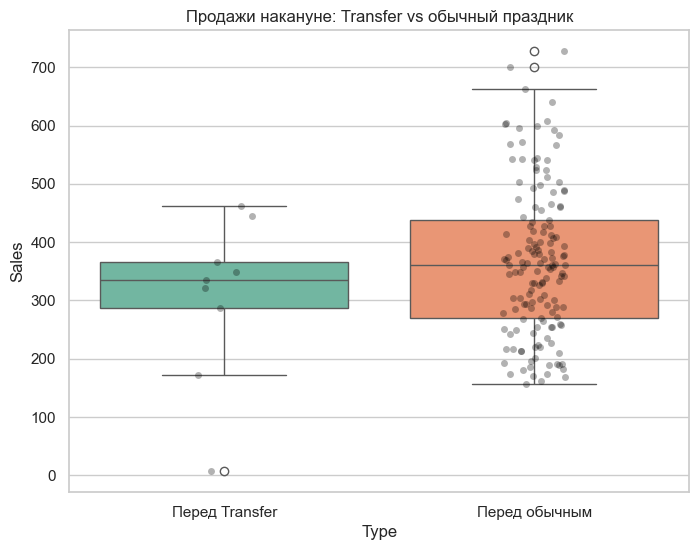

Mann-Whitney U: stat=540.0, p-value=0.8371
Средние: Transfer=304.4, Regular=366.5
Вывод: НЕ значимо (p>=0.05)


In [3]:
transfer_days = holidays[holidays['type'] == 'Transfer']['date']
regular_holidays = holidays[
    (holidays['type'] == 'Holiday') & (holidays['transferred'] == False)
]['date']

def get_pre_holiday_sales(dates):
    pre_dates = [d - pd.Timedelta(days=1) for d in dates]
    return train[train['date'].isin(pre_dates)].groupby('date')['sales'].mean().values

sales_before_transfer = get_pre_holiday_sales(transfer_days)
sales_before_regular = get_pre_holiday_sales(regular_holidays)

fig, ax = plt.subplots(figsize=(8, 6))
df_compare = pd.concat([
    pd.DataFrame({'Sales': sales_before_transfer, 'Type': 'Перед Transfer'}),
    pd.DataFrame({'Sales': sales_before_regular, 'Type': 'Перед обычным'})
])
sns.boxplot(data=df_compare, x='Type', y='Sales', palette='Set2', ax=ax)
sns.stripplot(data=df_compare, x='Type', y='Sales', color='black', alpha=0.3, ax=ax)
ax.set_title('Продажи накануне: Transfer vs обычный праздник')
plt.show()

stat, pval = stats.mannwhitneyu(sales_before_transfer, sales_before_regular, alternative='greater')
print(f'Mann-Whitney U: stat={stat:.1f}, p-value={pval:.4f}')
print(f'Средние: Transfer={np.mean(sales_before_transfer):.1f}, Regular={np.mean(sales_before_regular):.1f}')
print(f'Вывод: {"Значимо (p<0.05)" if pval < 0.05 else "НЕ значимо (p>=0.05)"}')

## Гипотеза 3: запаздывание цен на нефть

Корреляция между ценами на нефть и продажами сильнее при запаздывании в 2–4 недели.

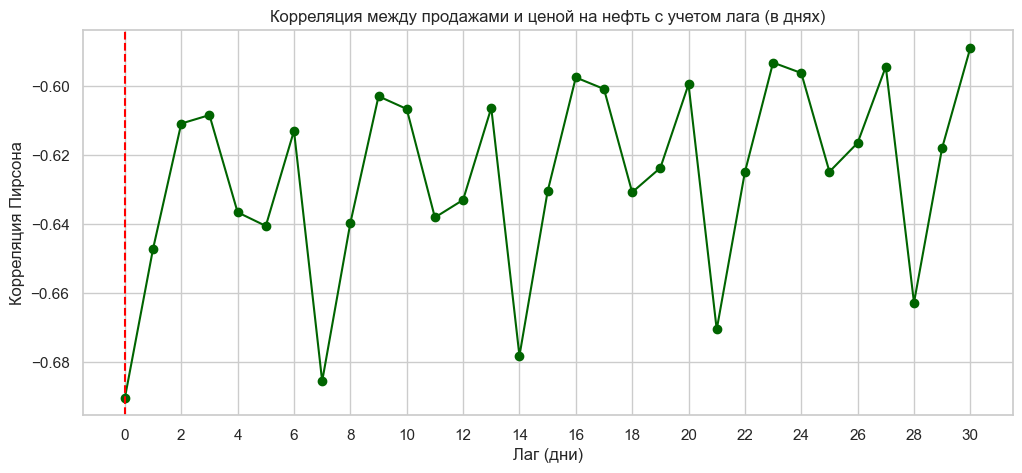

In [4]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()
oil_data = oil.copy().rename(columns={'dcoilwtico': 'oil_price'})
oil_data['oil_price'] = oil_data['oil_price'].ffill()
merged = pd.merge(daily_sales, oil_data, on='date', how='left')

lags = list(range(0, 31))
corrs = [merged['sales'].corr(merged['oil_price'].shift(lag)) for lag in lags]

plt.figure(figsize=(12, 5))
plt.plot(lags, corrs, marker='o', linestyle='-', color='darkgreen')
plt.axvline(0, color='red', linestyle='--')
plt.title("Корреляция между продажами и ценой на нефть с учетом лага (в днях)")
plt.xlabel("Лаг (дни)")
plt.ylabel("Корреляция Пирсона")
plt.xticks(lags[::2])
plt.show()

## Гипотеза 4: эффект промоакций по сравнению с эффектом повышения зарплаты

Промоакции сглаживают скачок выплат в день зарплаты (15/30 числа).

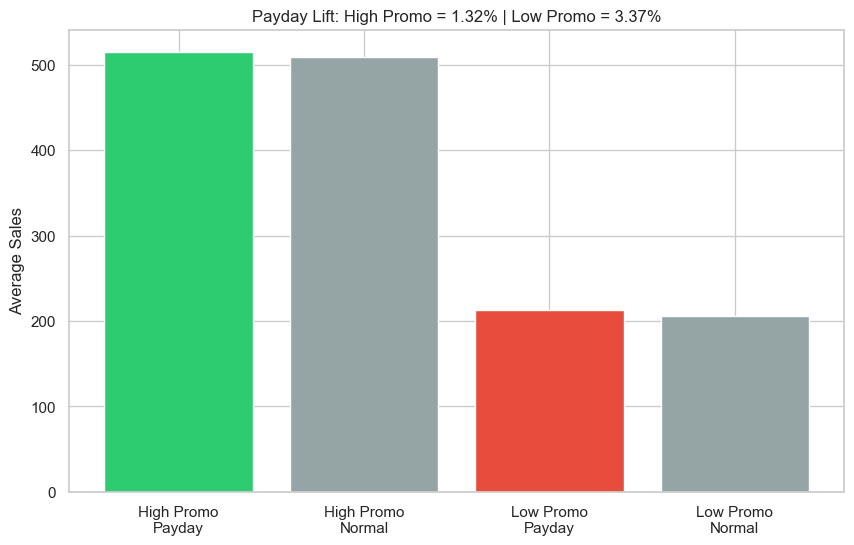

High Promo — Mann-Whitney p=0.432154
Low Promo  — Mann-Whitney p=0.152371


In [5]:
store_promo = train.groupby('store_nbr')['onpromotion'].mean()
high_promo_stores = set(store_promo[store_promo > store_promo.median()].index)
low_promo_stores = set(store_promo[store_promo <= store_promo.median()].index)

is_payday = train['date'].dt.day.isin([15, 30]) | train['date'].dt.is_month_end

def calc_lift(store_set):
    mask = train['store_nbr'].isin(store_set)
    pay = train.loc[mask & is_payday, 'sales']
    nopay = train.loc[mask & ~is_payday, 'sales']
    lift = (pay.mean() / nopay.mean() - 1) * 100
    return pay, nopay, lift

hp_pay, hp_nopay, hp_lift = calc_lift(high_promo_stores)
lp_pay, lp_nopay, lp_lift = calc_lift(low_promo_stores)

labels = ['High Promo\nPayday', 'High Promo\nNormal', 'Low Promo\nPayday', 'Low Promo\nNormal']
means = [hp_pay.mean(), hp_nopay.mean(), lp_pay.mean(), lp_nopay.mean()]
colors = ['#2ecc71', '#95a5a6', '#e74c3c', '#95a5a6']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, means, color=colors)
ax.set_ylabel('Average Sales')
ax.set_title(f'Payday Lift: High Promo = {hp_lift:.2f}% | Low Promo = {lp_lift:.2f}%')
plt.show()

stat_hp, p_hp = stats.mannwhitneyu(hp_pay.sample(10000, random_state=42), hp_nopay.sample(10000, random_state=42))
stat_lp, p_lp = stats.mannwhitneyu(lp_pay.sample(10000, random_state=42), lp_nopay.sample(10000, random_state=42))
print(f'High Promo — Mann-Whitney p={p_hp:.6f}')
print(f'Low Promo  — Mann-Whitney p={p_lp:.6f}')

## Hypothesis 5: School Supplies Seasonality

**Hypothesis:** SCHOOL AND OFFICE SUPPLIES spike 2-3 weeks before school starts (January).

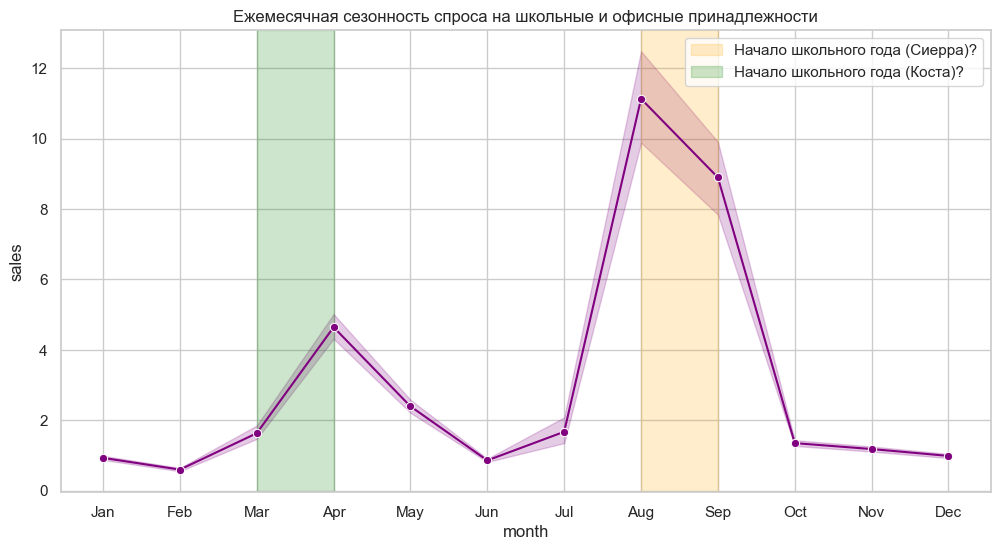

In [6]:
school_family = 'SCHOOL AND OFFICE SUPPLIES'
school_data = train[train['family'] == school_family].copy()
school_data['month'] = school_data['date'].dt.month

plt.figure(figsize=(12, 6))
sns.lineplot(data=school_data, x='month', y='sales', estimator='mean', marker='o', color='purple')
plt.title("Ежемесячная сезонность спроса на школьные и офисные принадлежности")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axvspan(8, 9, color='orange', alpha=0.2, label='Начало школьного года (Сиерра)?')
plt.axvspan(3, 4, color='green', alpha=0.2, label='Начало школьного года (Коста)?')
plt.legend()
plt.show()